In [ ]:
# Dataset used: us_counties_covid19.csv (Kaggle: https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-usa)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:
df = pd.read_csv("us_counties_covid19_daily.csv")

In [ ]:
display(df[:10])

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1.0,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1.0,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1.0,0.0
3,2020-01-24,Cook,Illinois,17031.0,1.0,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1.0,0.0
5,2020-01-25,Orange,California,6059.0,1.0,0.0
6,2020-01-25,Cook,Illinois,17031.0,1.0,0.0
7,2020-01-25,Snohomish,Washington,53061.0,1.0,0.0
8,2020-01-26,Maricopa,Arizona,4013.0,1.0,0.0
9,2020-01-26,Los Angeles,California,6037.0,1.0,0.0


In [ ]:
# Stylize the graph
sns.set_theme(style="whitegrid")

# Load data as is custom
df = pd.read_csv('us_counties_covid19_daily.csv')
df['date'] = pd.to_datetime(df['date'])

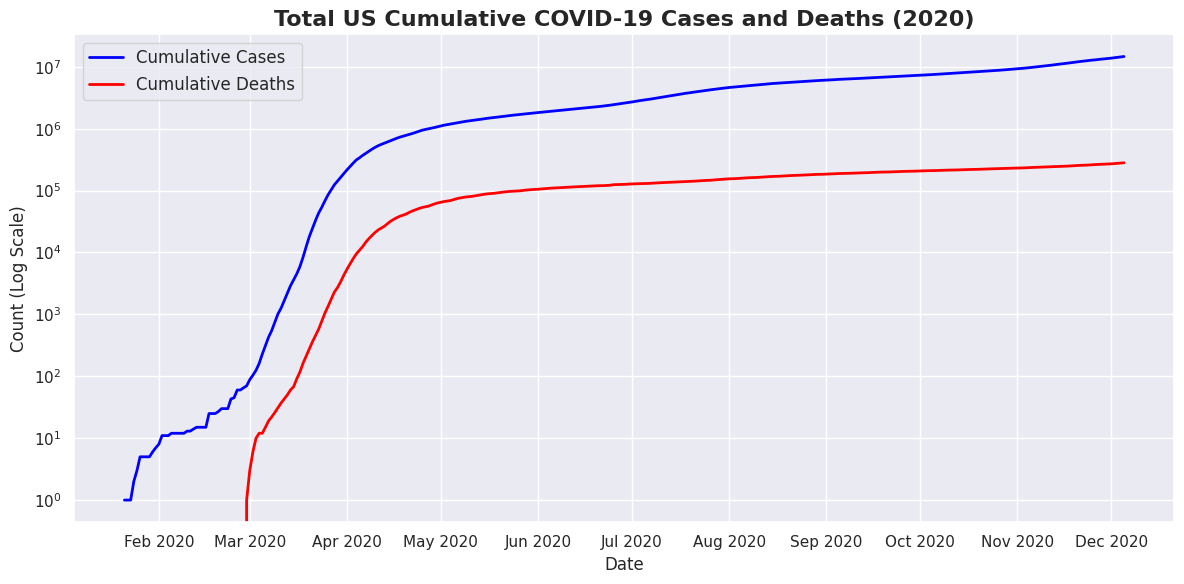

In [ ]:
# Plot 1: National Cumulative Trend (Log Scale) - Measuring magntitude
national_df = df.groupby('date')[['cases', 'deaths']].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(national_df['date'], national_df['cases'], label='Cumulative Cases', color='blue', linewidth=2)
plt.plot(national_df['date'], national_df['deaths'], label='Cumulative Deaths', color='red', linewidth=2)
plt.title('Total US Cumulative COVID-19 Cases and Deaths (2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count (Log Scale)', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.style.use('bmh')
plt.savefig('national_cumulative.png', dpi=150)
plt.show()

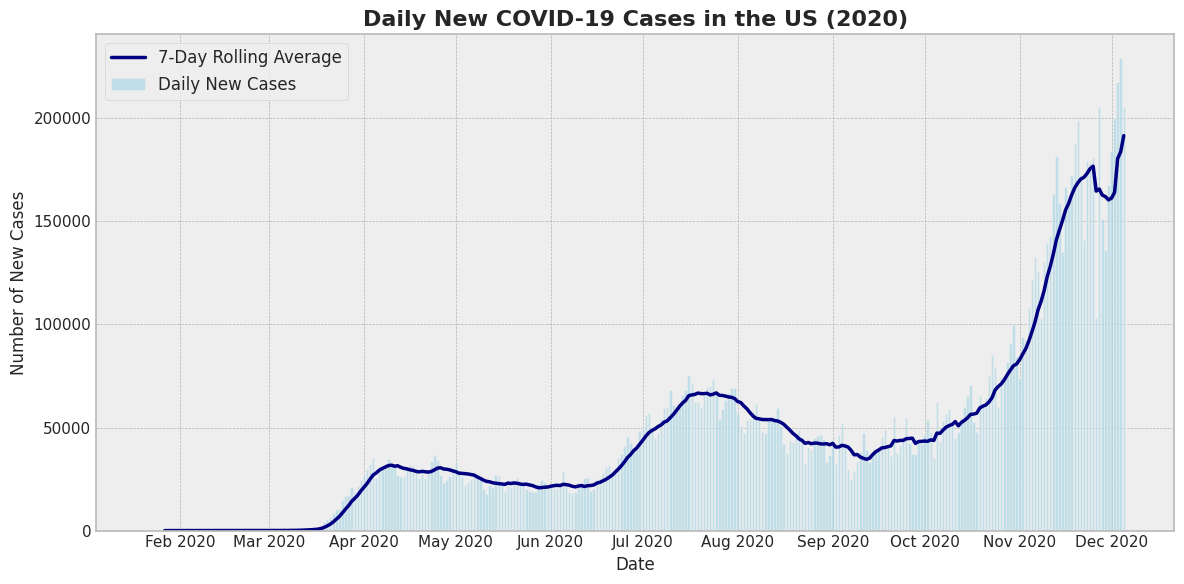

In [ ]:
# Plot 2: National Daily New Cases (7-Day Avg)
national_df['new_cases'] = national_df['cases'].diff().fillna(0)
national_df['new_cases_7day_avg'] = national_df['new_cases'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.bar(national_df['date'], national_df['new_cases'], color='lightblue', alpha=0.7, label='Daily New Cases')
plt.plot(national_df['date'], national_df['new_cases_7day_avg'], color='navy', linewidth=2.5, label='7-Day Rolling Average')
plt.title('Daily New COVID-19 Cases in the US (2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of New Cases', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('daily_new_cases.png', dpi=150)
plt.show()

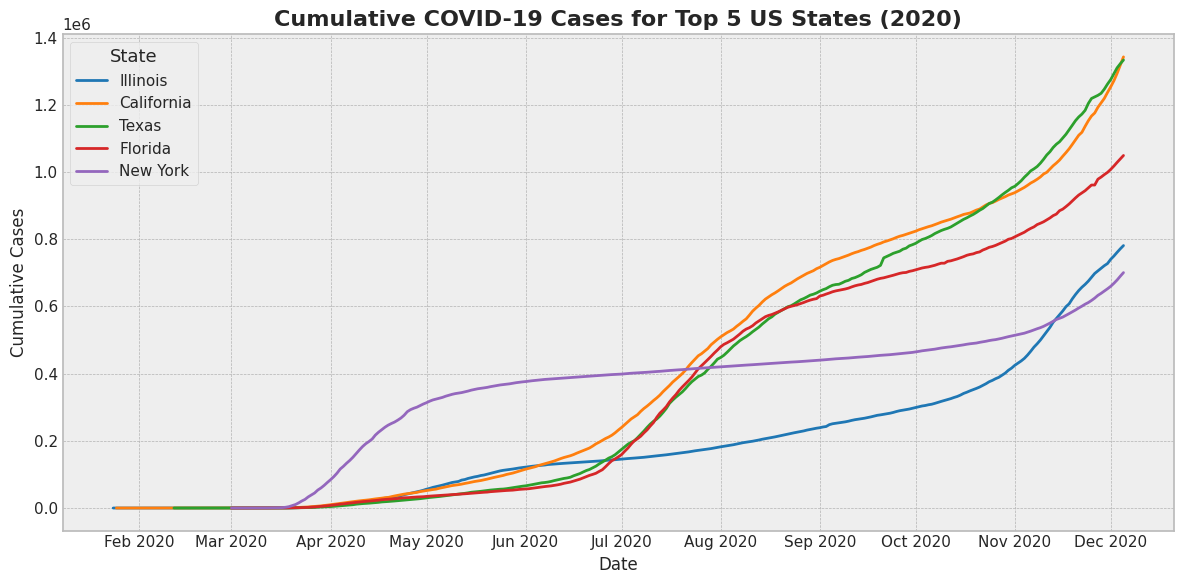

In [ ]:
# Plot 3: Top 5 States Comparison
last_day = df['date'].max()
top_5_states = df[df['date'] == last_day].groupby('state')['cases'].sum().nlargest(5).index
state_df = df[df['state'].isin(top_5_states)].groupby(['date', 'state'])['cases'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=state_df, x='date', y='cases', hue='state', linewidth=2, palette='tab10')
plt.title('Cumulative COVID-19 Cases for Top 5 US States (2020)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Cases', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.legend(title='State', title_fontsize='13', fontsize='11', loc='upper left')
plt.tight_layout()
plt.savefig('top_states.png', dpi=150)
plt.show()

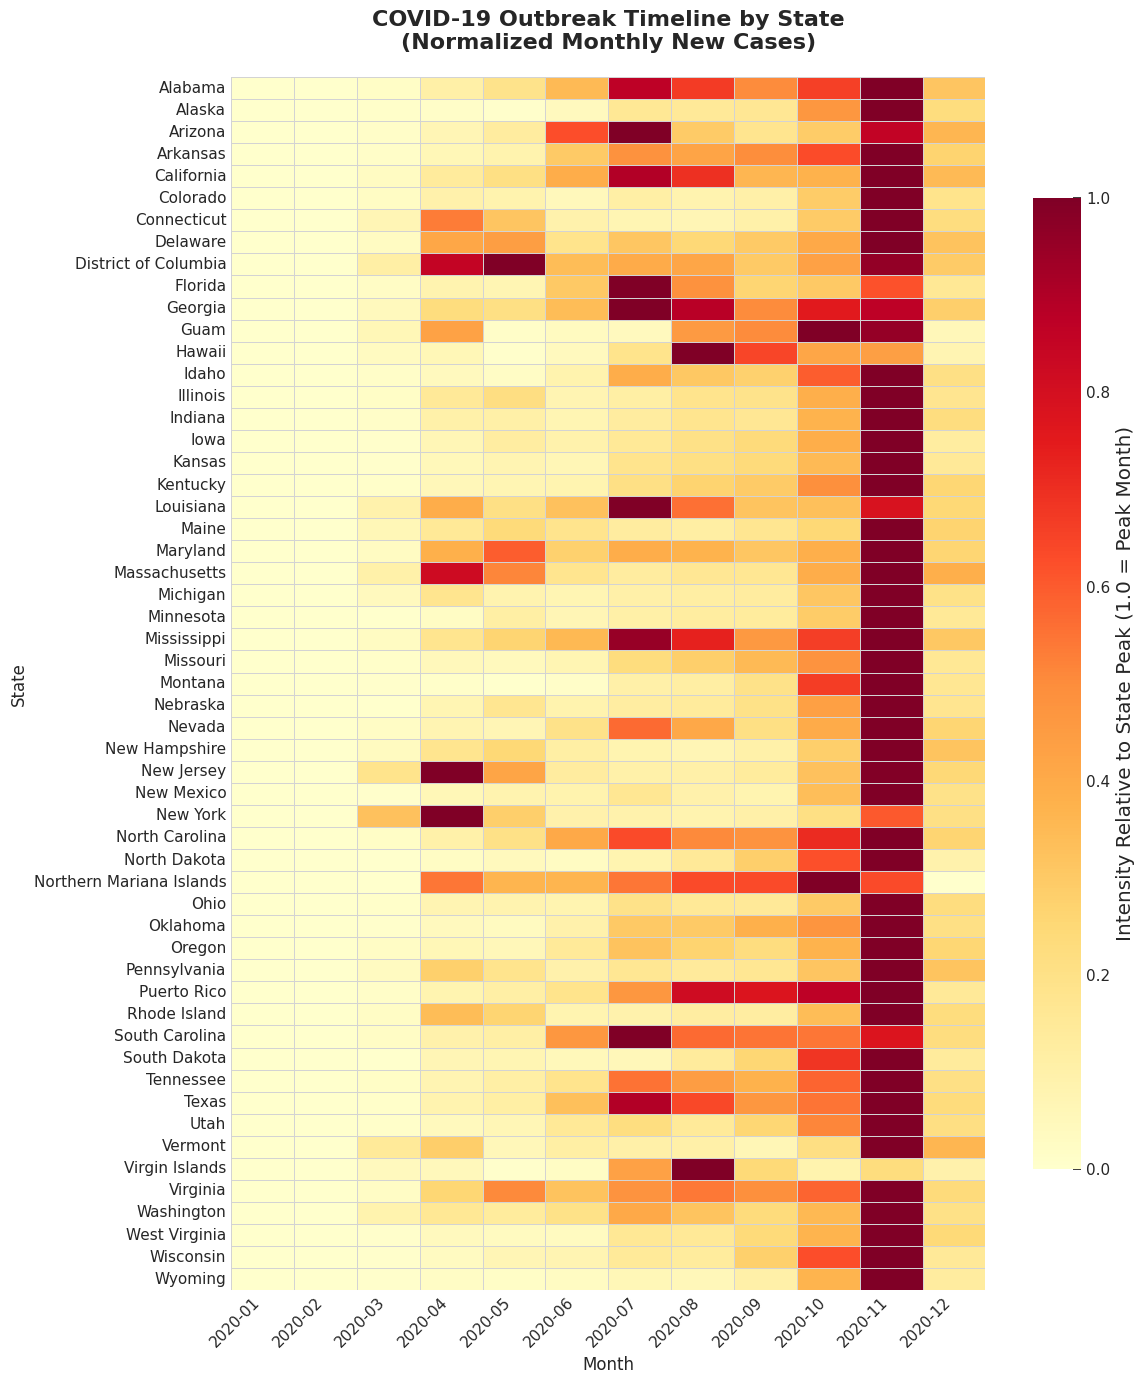

In [ ]:
# Plot 4: Heatmap - COVID-19 Outbreak Timeline by State
state_daily = df.groupby(['state', 'date'])['cases'].sum().reset_index()
state_daily = state_daily.sort_values(['state', 'date'])

# Calculate daily new cases
state_daily['new_cases'] = state_daily.groupby('state')['cases'].diff().fillna(0).clip(lower=0)

# Extract Year-Month and pivot
state_daily['year_month'] = state_daily['date'].dt.to_period('M').astype(str)
monthly_cases = state_daily.groupby(['state', 'year_month'])['new_cases'].sum().unstack(fill_value=0)

# Normalize row-by-row (state peak = 1.0)
heatmap_norm = monthly_cases.div(monthly_cases.max(axis=1), axis=0)

plt.figure(figsize=(12, 14))
sns.heatmap(heatmap_norm, cmap='YlOrRd', linewidths=0.5, linecolor='lightgray',
            cbar_kws={'label': 'Intensity Relative to State Peak (1.0 = Peak Month)', 'shrink': 0.8})
plt.title('COVID-19 Outbreak Timeline by State\n(Normalized Monthly New Cases)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('state_heatmap.png', dpi=150)
plt.show()